### **3RA PRE-ENTREGA - PROYECTO FINAL (ARTIFICIAL INTELLIGENCE I 2025-1)**

---

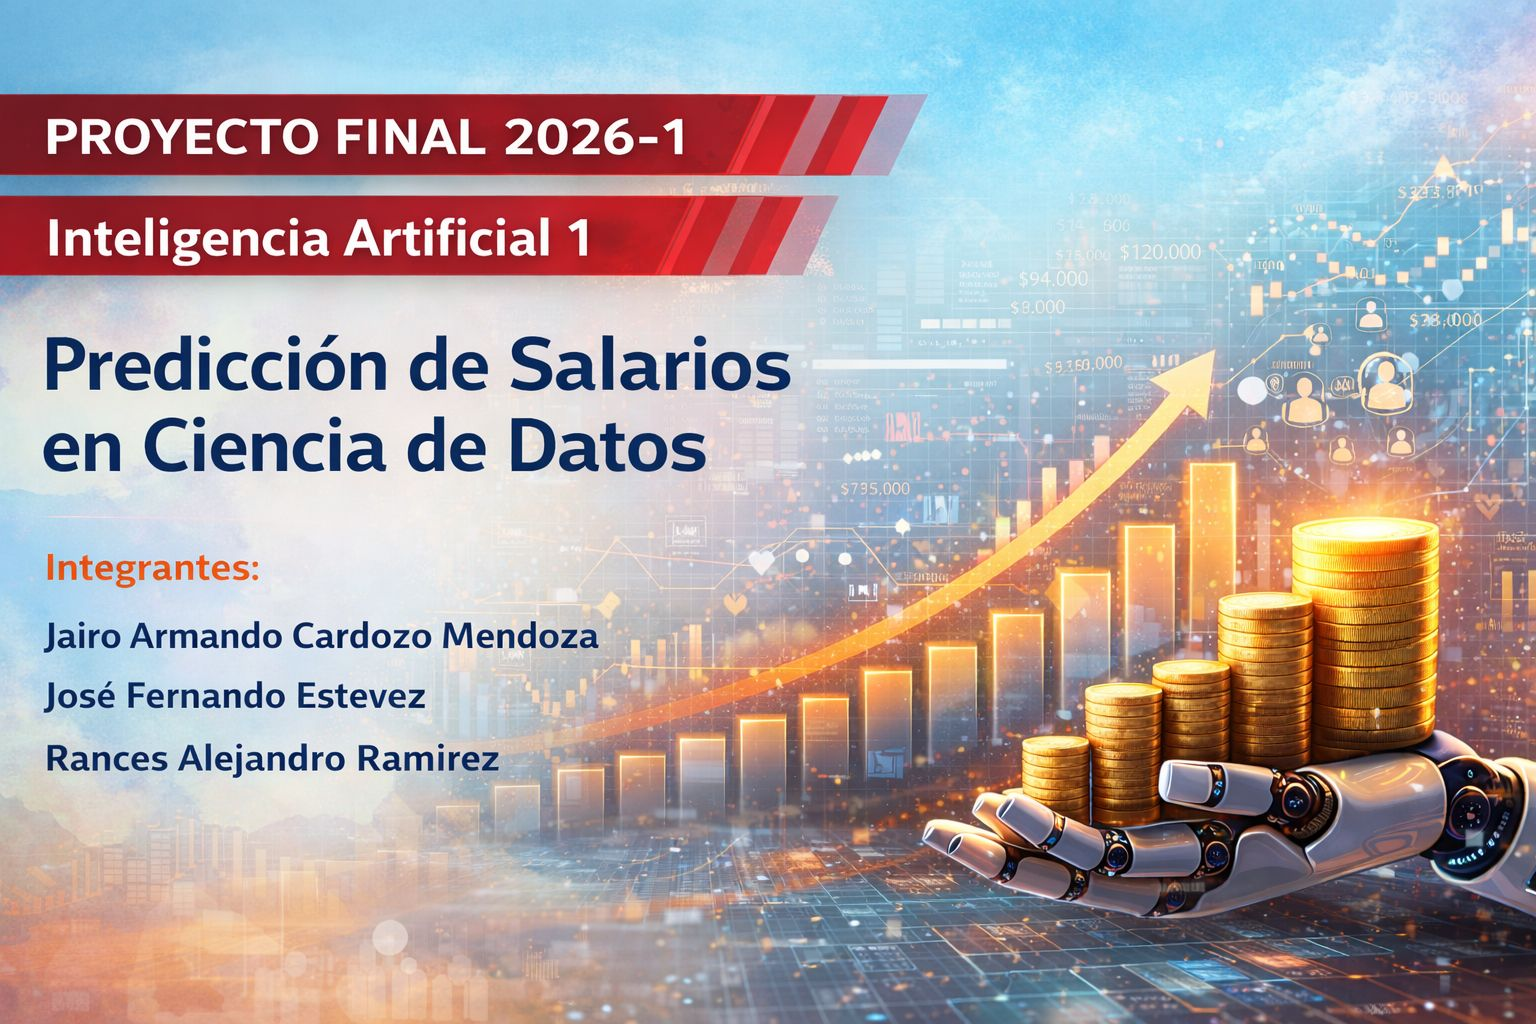

# **Autores:**

Jairo Armando Cardozo Mendoza — 2224637

Jose Fernando Estévez Cárdenas — 2224646

Rances Alejandro Ramirez Morillo — 2234514


# **Objetivo:**

Desarrollar un modelo capaz de analizar diferentes variables relacionadas con profesionales del área de ciencia de datos, con el fin de estimar y predecir el salario de estos profesionales a partir de la información disponible, utilizando inteligencia artificial.

# **Dataset:**

Dataset con aproximadamente 14,838 registros y 11 variables, que contienen información sobre empleos en el área de ciencia de datos entre 2020 y 2024.

# **Enlace de descarga del dataset:**

https://www.kaggle.com/datasets/yusufdelikkaya/datascience-salaries-2024/data

## Introducción al Dataset

Para este proyecto se utiliza el dataset Data Science Salaries, que contiene información sobre trabajos relacionados con ciencia de datos. El conjunto de datos incluye variables como el nivel de experiencia, tipo de empleo, cargo, ubicación de la empresa y salario.

El objetivo de usar este dataset es analizar los factores que influyen en los salarios dentro del área de ciencia de datos y utilizar esta información para desarrollar un modelo que permita predecir el salario en dólares (salary_in_usd) a partir de diferentes características laborales.

In [ ]:
# --- 1) Libreria Importadas---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [ ]:
# --- 2) Cargar dataset ---
file_id = "1z3shDrg20ddQwxnL8GULNqRQ0YU5oz8i"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

print("Cargando dataset desde Google Drive...")
df = pd.read_csv(url)
print("Dataset cargado exitosamente. Filas y columnas:", df.shape)

# --- 3) Requeridos por el profesor: shape / head / describe / columns / info ---
print("SHAPE:", df.shape)

print("\nHEAD:")
display(df.head(5))

print("\nDESCRIBE:")
display(df.describe(include="all").T)

print("\nCOLUMNS:", df.columns.tolist())

print("\nINFO:")
df.info()

Cargando dataset desde Google Drive...
Dataset cargado exitosamente. Filas y columnas: (14838, 11)
SHAPE: (14838, 11)

HEAD:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
3,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
4,2022,SE,FT,Lead Machine Learning Engineer,7500000,INR,95386,IN,50,IN,L



DESCRIBE:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,14838.0,NaN,NaN,NaN,2023.1389,0.700799,2020.0,2023.0,2023.0,2024.0,2024.0
experience_level,14838,4,SE,9696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,14838,4,FT,14772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,14838,153,Data Engineer,3162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,14838.0,NaN,NaN,NaN,165022.718965,356235.426522,14000.0,102100.0,142200.0,187500.0,30400000.0
salary_currency,14838,23,USD,13682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,14838.0,NaN,NaN,NaN,149874.718763,69009.181349,15000.0,102000.0,141300.0,185900.0,800000.0
employee_residence,14838,88,US,12926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,14838.0,NaN,NaN,NaN,32.76048,46.488278,0.0,0.0,0.0,100.0,100.0
company_location,14838,77,US,12975,NaN,NaN,NaN,NaN,NaN,NaN,NaN



COLUMNS: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14838 entries, 0 to 14837
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           14838 non-null  int64 
 1   experience_level    14838 non-null  object
 2   employment_type     14838 non-null  object
 3   job_title           14838 non-null  object
 4   salary              14838 non-null  int64 
 5   salary_currency     14838 non-null  object
 6   salary_in_usd       14838 non-null  int64 
 7   employee_residence  14838 non-null  object
 8   remote_ratio        14838 non-null  int64 
 9   company_location    14838 non-null  object
 10  company_size        14838 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.2+ MB


In [ ]:
# --- 4) Explicar significado de cada columna
pd.set_option("display.max_colwidth", None)

desc = {
    "work_year": "Año del salario",
    "experience_level": "Nivel: EN Entry, MI Mid, SE Senior, EX Executive",
    "employment_type": "Tipo empleo: FT full-time, PT part-time, CT contract, FL freelance",
    "job_title": "Cargo / Rol",
    "salary": "Salario en moneda original",
    "salary_currency": "Moneda original",
    "salary_in_usd": "Salario en USD",
    "employee_residence": "País de residencia del empleado (código)",
    "remote_ratio": "Porcentaje remoto (0/50/100)",
    "company_location": "País de la empresa (código)",
    "company_size": "Tamaño empresa (S/M/L)"
}

meaning = pd.DataFrame({
    "columna": df.columns,
    "significado": [desc.get(c, "Sin descripcion (revisar dataset)") for c in df.columns]
})

assert "salary_in_usd" in df.columns, "No existe la columna target 'salary_in_usd' en el dataset"  # validación

display(meaning)

,columna,significado
0,work_year,Año del salario
1,experience_level,"Nivel: EN Entry, MI Mid, SE Senior, EX Executive"
2,employment_type,"Tipo empleo: FT full-time, PT part-time, CT contract, FL freelance"
3,job_title,Cargo / Rol
4,salary,Salario en moneda original
5,salary_currency,Moneda original
6,salary_in_usd,Salario en USD
7,employee_residence,País de residencia del empleado (código)
8,remote_ratio,Porcentaje remoto (0/50/100)
9,company_location,País de la empresa (código)


In [ ]:
# --- 5) Identificar columnas numéricas y categóricas ---
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
print("NUMERIC:", num_cols)
print("CATEGORICAL:", cat_cols)

NUMERIC: ['work_year', 'salary', 'salary_in_usd', 'remote_ratio']
CATEGORICAL: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


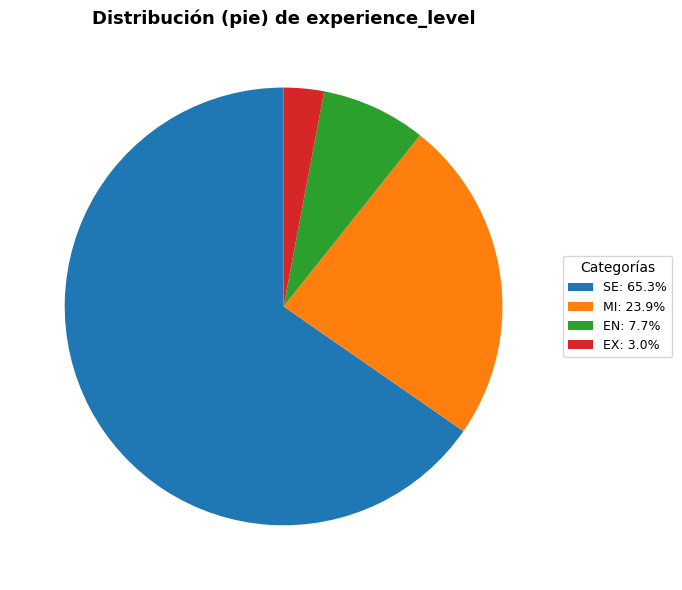


Leyenda — experience_level:
  SE: 65.3%
  MI: 23.9%
  EN: 7.7%
  EX: 3.0%


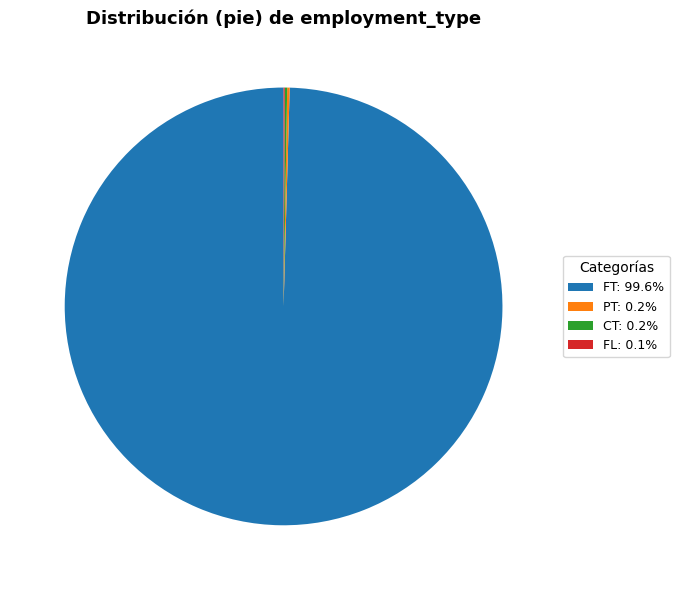


Leyenda — employment_type:
  FT: 99.6%
  PT: 0.2%
  CT: 0.2%
  FL: 0.1%


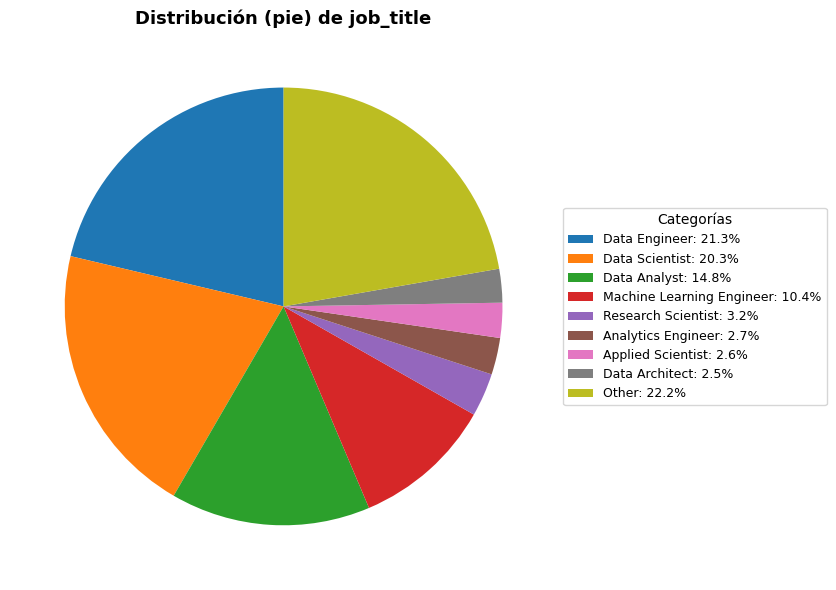


Leyenda — job_title:
  Data Engineer: 21.3%
  Data Scientist: 20.3%
  Data Analyst: 14.8%
  Machine Learning Engineer: 10.4%
  Research Scientist: 3.2%
  Analytics Engineer: 2.7%
  Applied Scientist: 2.6%
  Data Architect: 2.5%
  Other: 22.2%


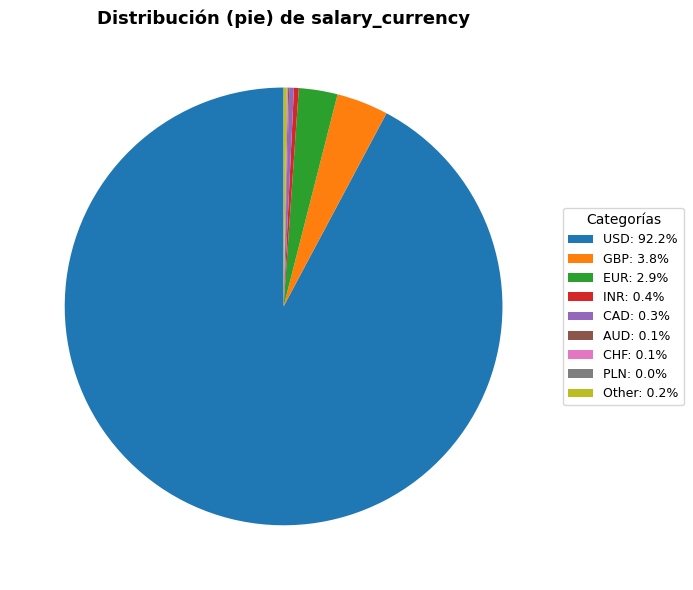


Leyenda — salary_currency:
  USD: 92.2%
  GBP: 3.8%
  EUR: 2.9%
  INR: 0.4%
  CAD: 0.3%
  AUD: 0.1%
  CHF: 0.1%
  PLN: 0.0%
  Other: 0.2%


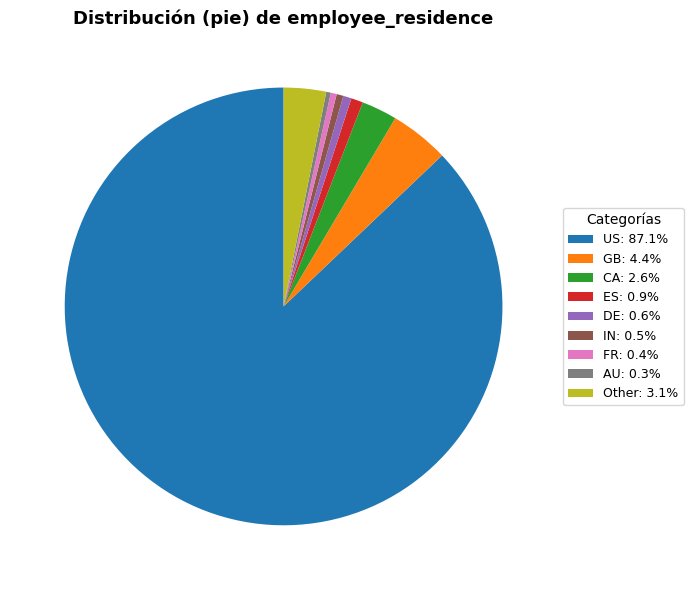


Leyenda — employee_residence:
  US: 87.1%
  GB: 4.4%
  CA: 2.6%
  ES: 0.9%
  DE: 0.6%
  IN: 0.5%
  FR: 0.4%
  AU: 0.3%
  Other: 3.1%


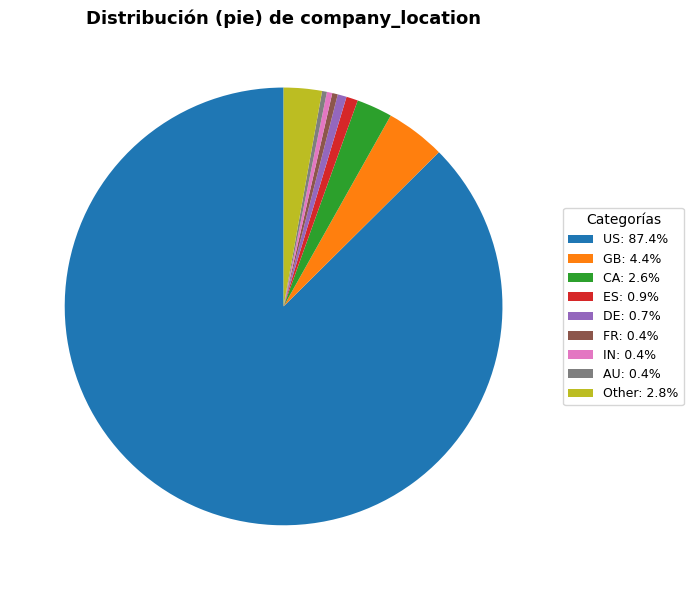


Leyenda — company_location:
  US: 87.4%
  GB: 4.4%
  CA: 2.6%
  ES: 0.9%
  DE: 0.7%
  FR: 0.4%
  IN: 0.4%
  AU: 0.4%
  Other: 2.8%


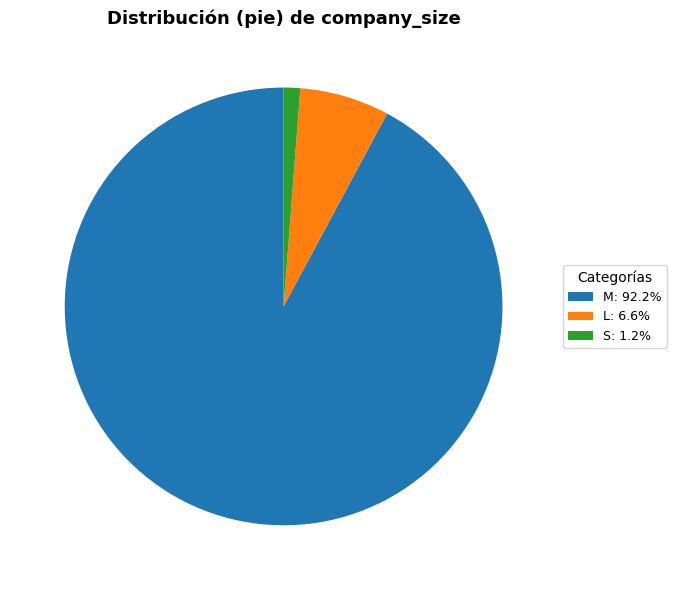


Leyenda — company_size:
  M: 92.2%
  L: 6.6%
  S: 1.2%


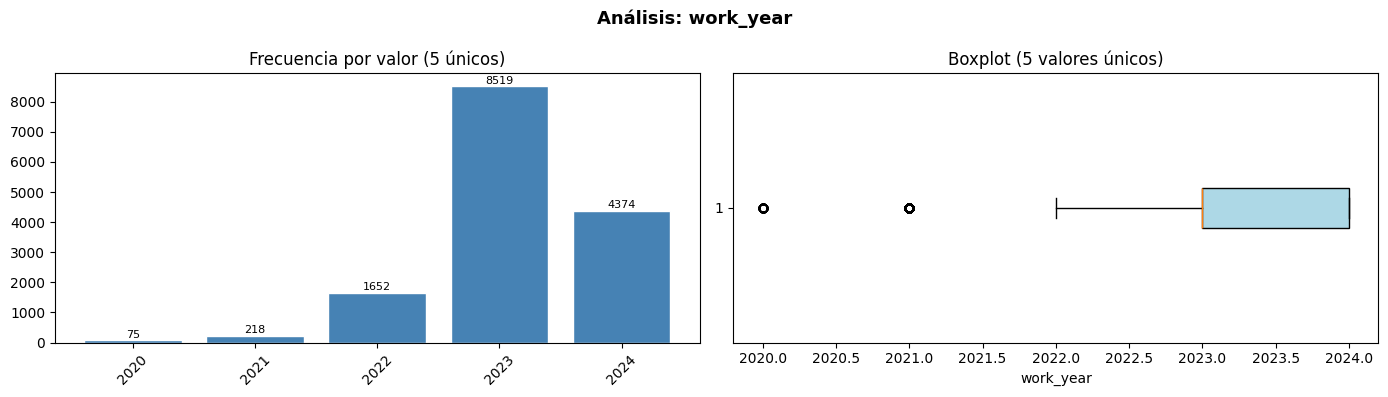


📊 work_year: min=2,020.0 | p25=2,023.0 | median=2,023.0 | p75=2,024.0 | max=2,024.0 | outliers=293 (2.0%)


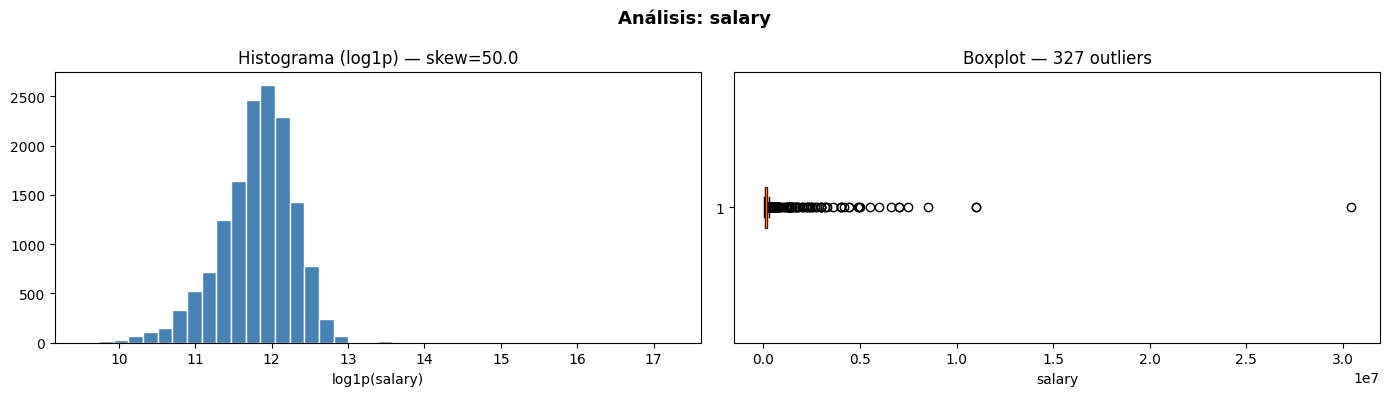


📊 salary: min=14,000.0 | p25=102,100.0 | median=142,200.0 | p75=187,500.0 | max=30,400,000.0 | outliers=327 (2.2%)


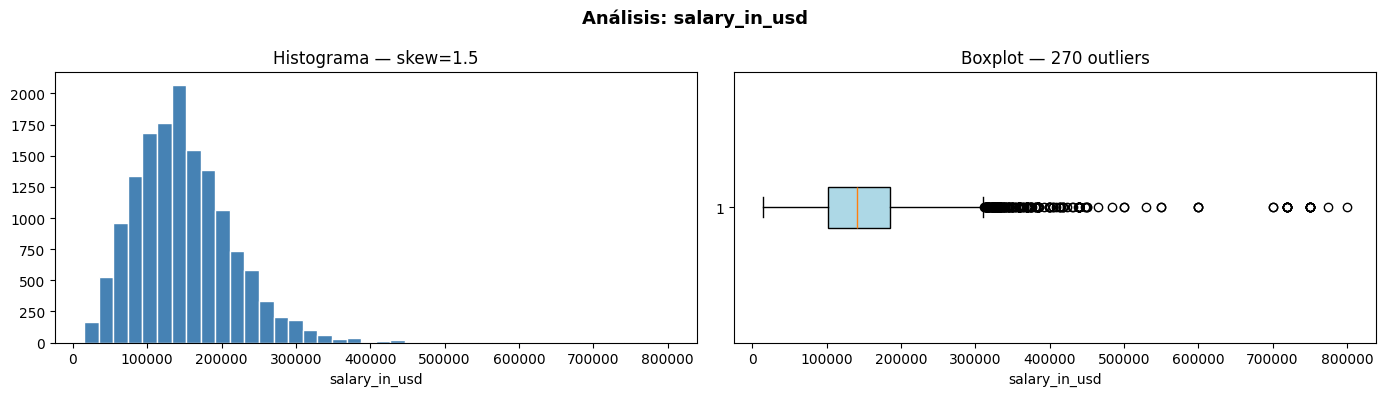


📊 salary_in_usd: min=15,000.0 | p25=102,000.0 | median=141,300.0 | p75=185,900.0 | max=800,000.0 | outliers=270 (1.8%)


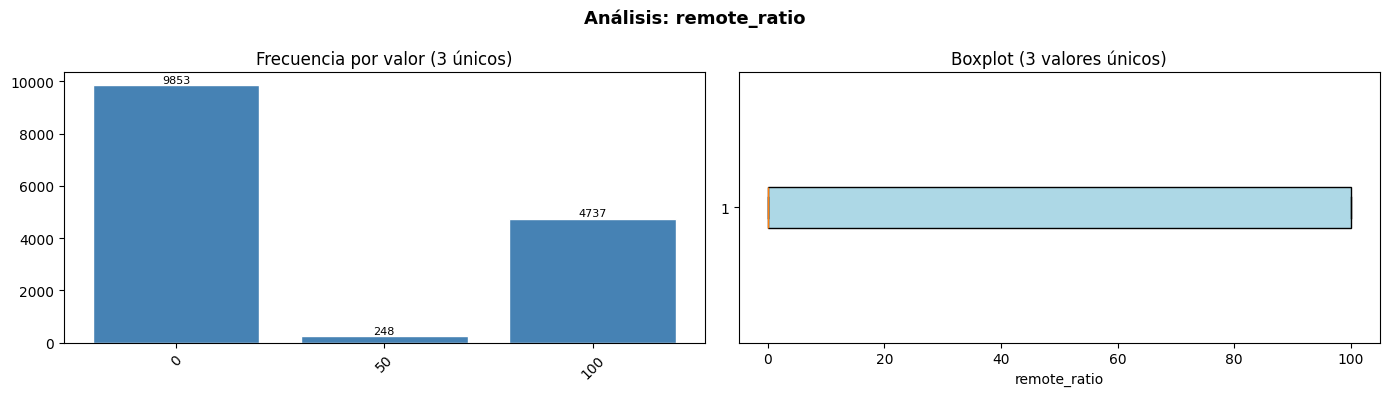


📊 remote_ratio: min=0.0 | p25=0.0 | median=0.0 | p75=100.0 | max=100.0 | outliers=0 (0.0%)


In [ ]:
# --- 6) EDA: Pie charts (categóricas) + plots inteligentes (numéricas) ---
def pie_solo_colores_y_lista(series, title=None, top_n=8, other_name="Other", min_pct_print=0.0):
    vc = series.value_counts(dropna=False)

    if top_n is not None and len(vc) > top_n:
        vc_plot = pd.concat([vc.iloc[:top_n], pd.Series({other_name: vc.iloc[top_n:].sum()})])
    else:
        vc_plot = vc

    pct = (vc_plot / vc_plot.sum()) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    wedges, _ = ax.pie(
        vc_plot.values,
        labels=None,
        autopct=None,
        startangle=90
    )
    ax.set_title(title or f"Distribución de {series.name}", fontsize=13, fontweight='bold')

    legend_labels = [
        f"{k}: {p:.1f}%"
        for k, p in zip(vc_plot.index.astype(str), pct.values)
        if p >= min_pct_print
    ]
    ax.legend(
        wedges[:len(legend_labels)],
        legend_labels,
        title="Categorías",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

    print(f"\nLeyenda — {series.name}:")
    for label in legend_labels:
        print(f"  {label}")


# ─────────────────────────────────────────────
# NUMÉRICAS: Gráfica inteligente según naturaleza del dato
# ─────────────────────────────────────────────
def _count_outliers(s):
    """Cuenta outliers por método IQR."""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()


def smart_plot_numeric(series, title=None):
    """Elige el mejor tipo de gráfica según la naturaleza del dato."""
    s = series.dropna()
    name = series.name
    n_unique = s.nunique()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title or f"Análisis: {name}", fontsize=13, fontweight='bold')

    # ── Panel izquierdo ──────────────────────────────────────
    if n_unique <= 15:
        # Variable discreta con pocos valores → barras de frecuencia
        vc = s.value_counts().sort_index()
        axes[0].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
        axes[0].set_title(f"Frecuencia por valor ({n_unique} únicos)")
        axes[0].tick_params(axis='x', rotation=45)
        for i, v in enumerate(vc.values):
            axes[0].text(i, v + max(vc.values) * 0.01, str(v), ha='center', fontsize=8)
    else:
        # Variable continua → histograma (log si muy sesgada)
        skewness = s.skew()
        if abs(skewness) > 2:
            axes[0].hist(np.log1p(s), bins=40, color='steelblue', edgecolor='white')
            axes[0].set_title(f"Histograma (log1p) — skew={skewness:.1f}")
            axes[0].set_xlabel(f"log1p({name})")
        else:
            axes[0].hist(s, bins=40, color='steelblue', edgecolor='white')
            axes[0].set_title(f"Histograma — skew={skewness:.1f}")
            axes[0].set_xlabel(name)

    # ── Panel derecho ─────────────────────────────────────────
    n_outliers = _count_outliers(s)
    pct_outliers = n_outliers / len(s)

    if n_unique <= 15:
        # Discreta: boxplot simple
        axes[1].boxplot(s, vert=False, showfliers=True,
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[1].set_title(f"Boxplot ({n_unique} valores únicos)")
    elif pct_outliers > 0.05:
        # Muchos outliers: recortar al percentil 99
        p99 = s.quantile(0.99)
        s_trim = s[s <= p99]
        axes[1].boxplot(s_trim, vert=False, showfliers=True,
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[1].set_title(f"Boxplot (recortado p99={p99:,.0f}) — {n_outliers} outliers totales")
    else:
        axes[1].boxplot(s, vert=False, showfliers=True,
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[1].set_title(f"Boxplot — {n_outliers} outliers")

    axes[1].set_xlabel(name)
    plt.tight_layout()
    plt.show()

    # Stats en consola
    print(f"\n📊 {name}: min={s.min():,.1f} | p25={s.quantile(.25):,.1f} | "
          f"median={s.median():,.1f} | p75={s.quantile(.75):,.1f} | "
          f"max={s.max():,.1f} | outliers={n_outliers} ({pct_outliers:.1%})")


# ─────────────────────────────────────────────
# EJECUTAR
# ─────────────────────────────────────────────
for c in cat_cols:
    pie_solo_colores_y_lista(df[c], top_n=8, title=f"Distribución (pie) de {c}")

for c in num_cols:
    smart_plot_numeric(df[c])

In [ ]:
# --- 7) Outliers con IQR (requerido) ---
def iqr_bounds(s, k=1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return q1, q3, iqr, lo, hi

iqr_report = []
for c in num_cols:
    s = df[c].dropna()
    if len(s) == 0:
        continue
    q1, q3, iqr, lo, hi = iqr_bounds(s)
    out = ((s < lo) | (s > hi)).sum()
    iqr_report.append([c, q1, q3, iqr, lo, hi, out, out/len(s)])

iqr_df = pd.DataFrame(
    iqr_report,
    columns=["col", "Q1", "Q3", "IQR", "lower", "upper", "#outliers", "%outliers"]
).sort_values("%outliers", ascending=False)

display(iqr_df)


,col,Q1,Q3,IQR,lower,upper,#outliers,%outliers
1,salary,102100.0,187500.0,85400.0,-26000.0,315600.0,327,0.022038
0,work_year,2023.0,2024.0,1.0,2021.5,2025.5,293,0.019747
2,salary_in_usd,102000.0,185900.0,83900.0,-23850.0,311750.0,270,0.018197
3,remote_ratio,0.0,100.0,100.0,-150.0,250.0,0,0.000000


---

# SEGUNDA PRE-ENTREGA

Proyecto de **REGRESION**: se predice `salary_in_usd` como valor continuo.

**Indice:**
1. [Limpieza del dataset](#req1)
2. [Particionado 80/20 + shuffle](#req2)
3. [Metodos de ML: DT, RF, SVM (regresion)](#req3)
4. [Cross-Validation](#req4)
5. [Deep Learning - Perceptron Multicapa (regresion)](#req5)
6. [Resumen de Resultados](#req6)


## 1. Limpieza del Dataset <a name="req1"></a>

Se eliminan duplicados, valores nulos y columnas redundantes.
Se codifican las variables categoricas.
El **target** es `salary_in_usd` (valor continuo → regresion).


In [ ]:
# --- Req. 1: Limpieza del dataset ---
# Basado en conceptos de 05_std_Notes_Pandas_Introduction.ipynb
import warnings
warnings.filterwarnings('ignore')

print("=== LIMPIEZA DEL DATASET ===")
print(f"Dimensiones originales: {df.shape}")

# 1.1 Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())
print(f"Total filas con algun nulo: {df.isnull().any(axis=1).sum()}")

# 1.2 Eliminar duplicados
df_clean = df.copy()
n_dup = df_clean.duplicated().sum()
print(f"\nFilas duplicadas encontradas: {n_dup}")
df_clean = df_clean.drop_duplicates()

# 1.3 Eliminar filas con nulos
df_clean = df_clean.dropna()
print(f"Dimensiones tras limpieza: {df_clean.shape}")

# 1.4 Eliminar columnas redundantes
# 'salary' esta en moneda original y 'salary_currency' son redundantes con 'salary_in_usd'
df_clean = df_clean.drop(columns=['salary', 'salary_currency'], errors='ignore')
print(f"Columnas finales: {df_clean.columns.tolist()}")
display(df_clean.head(3))


=== LIMPIEZA DEL DATASET ===
Dimensiones originales: (14838, 11)

Valores nulos por columna:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64
Total filas con algun nulo: 0

Filas duplicadas encontradas: 5711
Dimensiones tras limpieza: (9127, 11)
Columnas finales: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,35735,HU,50,HU,L


In [ ]:
# --- Req. 1 (cont.): Codificacion de categoricas ---
# Ref.: 08_std_Notes_Machine_learning_Introduction.ipynb - preparacion de features
# PROYECTO DE REGRESION: el target es salary_in_usd (valor continuo, SIN binear)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

df_model = df_clean.copy()

# Codificacion ordinal de experience_level (orden logico: EN < MI < SE < EX)
oe_exp = OrdinalEncoder(categories=[['EN', 'MI', 'SE', 'EX']],
                        handle_unknown='use_encoded_value', unknown_value=-1)
df_model['experience_level'] = oe_exp.fit_transform(df_model[['experience_level']])

# Codificacion ordinal de company_size (orden logico: S < M < L)
oe_size = OrdinalEncoder(categories=[['S', 'M', 'L']],
                         handle_unknown='use_encoded_value', unknown_value=-1)
df_model['company_size'] = oe_size.fit_transform(df_model[['company_size']])

# Codificacion de etiqueta para otras categoricas
le = LabelEncoder()
for col in ['employment_type', 'job_title', 'employee_residence', 'company_location']:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# --- Target y features (REGRESION) ---
feature_cols = [c for c in df_model.columns if c != 'salary_in_usd']
X = df_model[feature_cols].values
y = df_model['salary_in_usd'].values   # valor continuo en USD

print(f"TARGET (regresion): salary_in_usd")
print(f"  min=${y.min():,.0f}  max=${y.max():,.0f}  media=${y.mean():,.0f}  mediana=${np.median(y):,.0f}")
print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")
print(f"Features: {feature_cols}")


TARGET (regresion): salary_in_usd
  min=$15,000  max=$800,000  media=$146,752  mediana=$138,400

X shape: (9127, 8)  |  y shape: (9127,)
Features: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


## 2. Particionado 80/20 + Shuffle <a name="req2"></a>

Particion estratificada 80/20 con shuffle.
Se normalizan las features con StandardScaler (necesario para SVR y DL).
Ref.: **10_std_Notes_ML_Methods.ipynb** — celda *"code: Train-test split"*


In [ ]:
# --- Req. 2: Particionado 80/20 + shuffle ---
# Basado en: 10_std_Notes_ML_Methods.ipynb - train_test_split con test_size=0.2, shuffle=True
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    shuffle=True      # shuffle explicito (ref. pizarron)
)

print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Escalado de features — critico para SVR y beneficioso para DL
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

# Tambien escalamos y para que el DL converja mas facil (se desnormaliza al evaluar)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print(f"\nX_train_sc shape: {X_train_sc.shape}  (media~0, std~1)")
print(f"y_train rango: ${y_train.min():,.0f} - ${y_train.max():,.0f}")


Train: 7301 muestras (80.0%)
Test:  1826 muestras (20.0%)

X_train_sc shape: (7301, 8)  (media~0, std~1)
y_train rango: $15,000 - $800,000


## 3. Metodos de Machine Learning — Regresion <a name="req3"></a>

Se usan las versiones de **regresion** de los metodos vistos en clase:
- **DecisionTreeRegressor** — tuning de `max_depth`
- **RandomForestRegressor** — tuning de `n_estimators`
- **SVR** — kernels `linear`, `poly`, `rbf`

Metricas usadas: **MAE** (Error Absoluto Medio en USD), **RMSE** y **R²**
Ref.: **10_std_Notes_ML_Methods.ipynb** — secciones DT, RF, SVM


### 3.1 Decision Tree Regressor — Tuning: `max_depth`

In [ ]:
# --- Req. 3.1: Decision Tree Regressor ---
# Basado en: 10_std_Notes_ML_Methods.ipynb - 'Decision Tree classifier'
# Version REGRESION: DecisionTreeRegressor (mismo hiperparametro max_depth)
# Ref. pizarron: 'DT (tuning -> max_depth)'
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== 3.1 DECISION TREE REGRESSOR ===")

dt_results = {}
for depth in range(1, 21):
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    dt_results[depth] = {'mae': mae, 'rmse': rmse, 'r2': r2}

# Mejor por MAE (menor es mejor)
best_depth = min(dt_results, key=lambda d: dt_results[d]['mae'])
print(f"Mejor max_depth (menor MAE): {best_depth}")
print(f"  MAE  = ${dt_results[best_depth]['mae']:,.0f}")
print(f"  RMSE = ${dt_results[best_depth]['rmse']:,.0f}")
print(f"  R2   = {dt_results[best_depth]['r2']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
depths = list(dt_results.keys())
axes[0].plot(depths, [dt_results[d]['mae']  for d in depths], 'o-', color='steelblue')
axes[0].axvline(x=best_depth, color='red', linestyle='--', label=f'Mejor depth={best_depth}')
axes[0].set_xlabel('max_depth'); axes[0].set_ylabel('MAE (USD)'); axes[0].set_title('DT: MAE vs max_depth'); axes[0].legend()

axes[1].plot(depths, [dt_results[d]['r2']   for d in depths], 's-', color='coral')
axes[1].axvline(x=best_depth, color='red', linestyle='--', label=f'Mejor depth={best_depth}')
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('R2'); axes[1].set_title('DT: R2 vs max_depth'); axes[1].legend()
plt.tight_layout(); plt.show()

# Modelo final
dt_best = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print(f"\nFeature importances top-5:")
fi = dict(zip(feature_cols, dt_best.feature_importances_.round(3)))
for k,v in sorted(fi.items(), key=lambda x:-x[1])[:5]:
    print(f"  {k}: {v:.3f}")

results_summary = {'DT': {'MAE': mae_dt, 'RMSE': rmse_dt, 'R2': r2_dt}}


### 3.2 Random Forest Regressor — Tuning: `n_estimators`

In [ ]:
# --- Req. 3.2: Random Forest Regressor ---
# Basado en: 10_std_Notes_ML_Methods.ipynb - 'Random Forest classifier (RFC)'
# Version REGRESION: RandomForestRegressor
# Ref. pizarron: 'RF (tuning -> n_estimators)'
from sklearn.ensemble import RandomForestRegressor

print("=== 3.2 RANDOM FOREST REGRESSOR ===")

n_est_options = [10, 25, 50, 75, 100, 150, 200]
rf_results = {}
for n_est in n_est_options:
    rf = RandomForestRegressor(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    rf_results[n_est] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    print(f"  n_estimators={n_est:3d}: MAE=${mae:,.0f}  RMSE=${rmse:,.0f}  R2={r2:.4f}")

best_n_est = min(rf_results, key=lambda n: rf_results[n]['mae'])
print(f"\nMejor n_estimators (menor MAE): {best_n_est}")
print(f"  MAE  = ${rf_results[best_n_est]['mae']:,.0f}")
print(f"  RMSE = ${rf_results[best_n_est]['rmse']:,.0f}")
print(f"  R2   = {rf_results[best_n_est]['r2']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
nests = list(rf_results.keys())
axes[0].plot(nests, [rf_results[n]['mae'] for n in nests], 's-', color='forestgreen')
axes[0].axvline(x=best_n_est, color='red', linestyle='--', label=f'Mejor n={best_n_est}')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('MAE (USD)'); axes[0].set_title('RF: MAE vs n_estimators'); axes[0].legend()

axes[1].plot(nests, [rf_results[n]['r2']  for n in nests], 's-', color='mediumseagreen')
axes[1].axvline(x=best_n_est, color='red', linestyle='--', label=f'Mejor n={best_n_est}')
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('R2'); axes[1].set_title('RF: R2 vs n_estimators'); axes[1].legend()
plt.tight_layout(); plt.show()

rf_best = RandomForestRegressor(n_estimators=best_n_est, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
y_pred_rf = rf_best.predict(X_test)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

results_summary['RF'] = {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf}


### 3.3 Support Vector Regression (SVR) — Kernels: linear / poly / rbf

Ref.: **10_std_Notes_ML_Methods.ipynb** — seccion *'Support vector machine (SVM)'*
Version REGRESION: `SVR` en lugar de `SVC`.
Nota del pizarron: `kernel='poly'` marcado especialmente.
Se usan features escaladas (`X_train_sc`) porque SVR es sensible a la escala.


In [ ]:
# --- Req. 3.3: SVR (Support Vector Regression) ---
# Basado en: 10_std_Notes_ML_Methods.ipynb - 'Support vector machine (SVM)'
# Version REGRESION: SVR en lugar de SVC
# Ref. pizarron: 'SVM (linear/poly/rbf) <- kernel="poly"'
from sklearn.svm import SVR

print("=== 3.3 SUPPORT VECTOR REGRESSION (SVR) ===")
print("Usando features escaladas (StandardScaler).\n")

svr_kernels = ['linear', 'poly', 'rbf']
svr_results = {}

for kernel in svr_kernels:
    svr = SVR(kernel=kernel)
    svr.fit(X_train_sc, y_train)
    y_pred = svr.predict(X_test_sc)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    svr_results[kernel] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    print(f"--- Kernel: {kernel} ---")
    print(f"  MAE  = ${mae:,.0f}")
    print(f"  RMSE = ${rmse:,.0f}")
    print(f"  R2   = {r2:.4f}\n")

best_kernel = min(svr_results, key=lambda k: svr_results[k]['mae'])
print(f"Mejor kernel SVR (menor MAE): '{best_kernel}'  MAE=${svr_results[best_kernel]['mae']:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(svr_results.keys(), [svr_results[k]['mae'] for k in svr_results], color=['steelblue','coral','forestgreen'])
axes[0].set_ylabel('MAE (USD)'); axes[0].set_title('SVR: MAE por kernel')
for i,(k,v) in enumerate(svr_results.items()):
    axes[0].text(i, v + 200, f"${v:,.0f}", ha='center', fontsize=10)

axes[1].bar(svr_results.keys(), [svr_results[k]['r2'] for k in svr_results], color=['steelblue','coral','forestgreen'])
axes[1].set_ylabel('R2'); axes[1].set_title('SVR: R2 por kernel')
for i,(k,v) in enumerate(svr_results.items()):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)
plt.tight_layout(); plt.show()

results_summary['SVR'] = svr_results[best_kernel]


## 4. Cross-Validation <a name="req4"></a>

Se aplica **K-Fold Cross-Validation con K = 10** a todos los modelos de regresion.

### ¿Por que K = 10?

El pizarron indicaba elegir entre K = 10, 20 o 50. Se selecciono **K = 10** por las siguientes razones:

| Criterio | K = 10 | K = 20 | K = 50 |
|---|---|---|---|
| Estandar en literatura | ✓ Kohavi (1995), es el valor mas citado | neutro | no estandar |
| Tamano del fold (n≈14 800) | ~1 480 muestras de val. — suficiente | ~740 | ~296 — muy pequeno |
| Bias de la estimacion | Bajo | Muy bajo | Minimo |
| Varianza de la estimacion | Moderada — aceptable | Mayor | Alta |
| Costo computacional | 10 entrenamientos por modelo | 20 | 50 — muy costoso con SVR |
| Referencia del notebook de clase | 09_std_Notes_Classification.ipynb usa K=10 | — | — |

**Conclusion:** K = 10 da la mejor relacion entre **precision de la estimacion** y **costo computacional**.
Con K = 20 o 50 el MAE estimado cambia marginalamente, pero el tiempo de calculo crece 2x o 5x,
lo cual es especialmente costoso para SVR cuya complejidad es O(n²).

Ref.: **09_std_Notes_Classification.ipynb** — `KFold` y `cross_val_score`


In [ ]:
# --- Req. 4: Cross-Validation con K=10 ---
# K=10 seleccionado como el mas conveniente (justificacion en celda anterior)
# Basado en: 09_std_Notes_Classification.ipynb - cross_val_score con KFold
# Para regresion: scoring='neg_mean_absolute_error'
from sklearn.model_selection import KFold, cross_val_score

BEST_K = 10
print(f"=== 4. CROSS-VALIDATION K={BEST_K} — REGRESION ===\n")

X_full_sc = scaler_X.fit_transform(X)   # escala todo X para SVR en CV

estimators_cv = {
    'DT':         (DecisionTreeRegressor(max_depth=best_depth, random_state=42),               X),
    'RF':         (RandomForestRegressor(n_estimators=best_n_est, random_state=42, n_jobs=-1), X),
    'SVR-linear': (SVR(kernel='linear'), X_full_sc),
    'SVR-poly':   (SVR(kernel='poly'),   X_full_sc),
    'SVR-rbf':    (SVR(kernel='rbf'),    X_full_sc),
}

kf = KFold(n_splits=BEST_K, shuffle=True, random_state=42)

cv_results = {}
for name, (est, Xuse) in estimators_cv.items():
    scores = cross_val_score(
        est, Xuse, y,
        cv=kf,
        scoring='neg_mean_absolute_error'
    )
    mae_mean = float(-np.mean(scores))
    mae_std  = float(np.std(scores))
    cv_results[name] = (mae_mean, mae_std)
    print(f"{name:12s}: MAE=${mae_mean:,.0f} (+/- ${mae_std:,.0f})")

print()

# Grafica de barras con barras de error
fig, ax = plt.subplots(figsize=(10, 5))
palette = ['steelblue', 'forestgreen', 'coral', 'orange', 'purple']
names  = list(cv_results.keys())
means  = [cv_results[n][0] for n in names]
stds   = [cv_results[n][1] for n in names]
bars   = ax.bar(names, means, color=palette, edgecolor='black', alpha=0.85, yerr=stds, capsize=6)
ax.set_ylabel('MAE (USD)'); ax.set_title(f'Cross-Validation K={BEST_K}: MAE por Modelo (regresion)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

best_cv_model = min(cv_results, key=lambda n: cv_results[n][0])
print(f"Mejor modelo en CV (menor MAE): {best_cv_model}  MAE=${cv_results[best_cv_model][0]:,.0f}")
print(f"K utilizado: {BEST_K}  (estandar en literatura, buen balance sesgo-varianza-costo)")


## 5. Deep Learning — Perceptron Multicapa (Regresion) <a name="req5"></a>

Redes neuronales densas para **regresion**:
- Capa de salida: `Dense(1)` (un valor continuo, activacion lineal)
- Funcion de perdida: `mean_squared_error` (MSE)
- Metrica principal: `mae` (Mean Absolute Error en USD)

Ref.: **12_std_Notes_Intro_DL.ipynb** — modelo Sequential Dense
Ref.: **13_std_Notes_DL_application.ipynb** — arquitecturas profundas
Ref. pizarron: `#EPOCHS` *[elija el mas conveniente: 10, 50, 100]*


In [ ]:
# --- Req. 5: Preparacion de datos para Deep Learning ---
# Basado en: 13_std_Notes_DL_application.ipynb - preparacion de datos
# Para regresion NO se hace One-Hot Encoding del target
import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")

input_dim = X_train_sc.shape[1]
print(f"input_dim: {input_dim}  (features escaladas)")
print(f"y_train_sc: media={y_train_sc.mean():.4f}  std={y_train_sc.std():.4f}")
print("\nNOTA: y se escala con StandardScaler para mejor convergencia.")
print("Los resultados se DESNORMALIZAN con scaler_y.inverse_transform() para evaluar en USD.")


### 5.1 Arquitectura 1: input → [64, 128, 128] → 1

In [ ]:
# --- Req. 5: Arquitectura 1 ---
# Ref. pizarron: 'input, capas ocultas (64, 128, 128), output'
# Basado en: 12_std_Notes_Intro_DL.ipynb - modelo Sequential
# REGRESION: salida Dense(1) con activacion lineal (default), loss='mse'
EPOCHS = 50   # justificado en celda 5.4

print("=== Arquitectura 1: input -> [64, 128, 128] -> 1 (regresion) ===")

model_arch1 = tf.keras.Sequential([
    tf.keras.layers.Dense(64,  activation='relu', input_shape=(input_dim,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)   # salida lineal para regresion
], name='Arch1_64_128_128')

model_arch1.summary()

model_arch1.compile(
    optimizer='adam',
    loss='mse',          # Mean Squared Error para regresion
    metrics=['mae']      # Mean Absolute Error como metrica de seguimiento
)

history1 = model_arch1.fit(
    X_train_sc, y_train_sc,   # y escalado
    epochs=EPOCHS, batch_size=64,
    validation_data=(X_test_sc, y_test_sc),
    verbose=0
)

# Evaluar desnormalizando predicciones a USD reales
y_pred1_sc = model_arch1.predict(X_test_sc, verbose=0).ravel()
y_pred1    = scaler_y.inverse_transform(y_pred1_sc.reshape(-1,1)).ravel()
mae1  = mean_absolute_error(y_test, y_pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
r2_1  = r2_score(y_test, y_pred1)
print(f"\nArq. 1 | epochs={EPOCHS}: MAE=${mae1:,.0f}  RMSE=${rmse1:,.0f}  R2={r2_1:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history1.history['mae'],     label='Train MAE')
plt.plot(history1.history['val_mae'], label='Validacion MAE')
plt.title('Arch 1 - MAE (escalado)'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'],     label='Train MSE')
plt.plot(history1.history['val_loss'], label='Validacion MSE')
plt.title('Arch 1 - Loss (MSE, escalado)'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

results_summary['DL-Arch1'] = {'MAE': mae1, 'RMSE': rmse1, 'R2': r2_1}


### 5.2 Arquitectura 2: input → [64, 64, 128, 128, 256, 256] → 1

In [ ]:
# --- Req. 5: Arquitectura 2 ---
# Ref. pizarron: 'input, capas ocultas (64, 64, 128, 128, 256, 256), output'
# Ref.: 13_std_Notes_DL_application.ipynb - redes mas profundas
print("=== Arquitectura 2: input -> [64, 64, 128, 128, 256, 256] -> 1 ===")

model_arch2 = tf.keras.Sequential([
    tf.keras.layers.Dense(64,  activation='relu', input_shape=(input_dim,)),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1)
], name='Arch2_64_64_128_128_256_256')

model_arch2.summary()
model_arch2.compile(optimizer='adam', loss='mse', metrics=['mae'])

history2 = model_arch2.fit(
    X_train_sc, y_train_sc,
    epochs=EPOCHS, batch_size=64,
    validation_data=(X_test_sc, y_test_sc),
    verbose=0
)

y_pred2_sc = model_arch2.predict(X_test_sc, verbose=0).ravel()
y_pred2    = scaler_y.inverse_transform(y_pred2_sc.reshape(-1,1)).ravel()
mae2  = mean_absolute_error(y_test, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_2  = r2_score(y_test, y_pred2)
print(f"\nArq. 2 | epochs={EPOCHS}: MAE=${mae2:,.0f}  RMSE=${rmse2:,.0f}  R2={r2_2:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history2.history['mae'],     label='Train MAE')
plt.plot(history2.history['val_mae'], label='Validacion MAE')
plt.title('Arch 2 - MAE'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'],     label='Train MSE')
plt.plot(history2.history['val_loss'], label='Validacion MSE')
plt.title('Arch 2 - Loss (MSE)'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

results_summary['DL-Arch2'] = {'MAE': mae2, 'RMSE': rmse2, 'R2': r2_2}


### 5.3 Arquitectura 3: input → [128, 128, 128] → 1 (todas 128 neuronas)

In [ ]:
# --- Req. 5: Arquitectura 3 ---
# Ref. pizarron: 'input, capas ocultas (todas 128 neuronas), output'
print("=== Arquitectura 3: input -> [128, 128, 128] -> 1 ===")

model_arch3 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
], name='Arch3_128_128_128')

model_arch3.summary()
model_arch3.compile(optimizer='adam', loss='mse', metrics=['mae'])

history3 = model_arch3.fit(
    X_train_sc, y_train_sc,
    epochs=EPOCHS, batch_size=64,
    validation_data=(X_test_sc, y_test_sc),
    verbose=0
)

y_pred3_sc = model_arch3.predict(X_test_sc, verbose=0).ravel()
y_pred3    = scaler_y.inverse_transform(y_pred3_sc.reshape(-1,1)).ravel()
mae3  = mean_absolute_error(y_test, y_pred3)
rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
r2_3  = r2_score(y_test, y_pred3)
print(f"\nArq. 3 | epochs={EPOCHS}: MAE=${mae3:,.0f}  RMSE=${rmse3:,.0f}  R2={r2_3:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history3.history['mae'],     label='Train MAE')
plt.plot(history3.history['val_mae'], label='Validacion MAE')
plt.title('Arch 3 - MAE'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history3.history['loss'],     label='Train MSE')
plt.plot(history3.history['val_loss'], label='Validacion MSE')
plt.title('Arch 3 - Loss (MSE)'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

results_summary['DL-Arch3'] = {'MAE': mae3, 'RMSE': rmse3, 'R2': r2_3}


### 5.4 Comparacion de epocas: 10 / 50 / 100

Ref. pizarron: *#EPOCHS: [elija el mas conveniente: 10, 50, 100]*
Arquitectura 1 [64, 128, 128] como referencia.


In [ ]:
# --- Req. 5: Comparacion de #EPOCHS: 10, 50, 100 ---
# Ref. pizarron: '#EPOCHS: [elija el mas conveniente: 10, 50, 100]'
# Basado en: 12_std_Notes_Intro_DL.ipynb - parametro epochs en model.fit()
print("=== 5.4 Comparacion de EPOCHS: 10 / 50 / 100 ===")
print("Arquitectura 1 [64, 128, 128] como referencia.\n")

epochs_options = [10, 50, 100]
mae_by_epoch   = {}

for ep in epochs_options:
    m = tf.keras.Sequential([
        tf.keras.layers.Dense(64,  activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    m.fit(X_train_sc, y_train_sc, epochs=ep, batch_size=64, verbose=0)
    y_pred_sc = m.predict(X_test_sc, verbose=0).ravel()
    y_pred_ep = scaler_y.inverse_transform(y_pred_sc.reshape(-1,1)).ravel()
    mae = mean_absolute_error(y_test, y_pred_ep)
    mae_by_epoch[ep] = float(mae)
    print(f"  epochs={ep:3d}: MAE=${mae:,.0f}")

best_epochs = min(mae_by_epoch, key=mae_by_epoch.get)
print(f"\nMejor configuracion: epochs={best_epochs}  ->  MAE=${mae_by_epoch[best_epochs]:,.0f}")

plt.figure(figsize=(7, 4))
bar_colors = ['lightsteelblue', 'steelblue', 'darkblue']
bars_ep = plt.bar([str(e) for e in epochs_options], list(mae_by_epoch.values()), color=bar_colors)
plt.xlabel('Numero de epocas'); plt.ylabel('MAE (USD)')
plt.title('DL: Comparacion de #EPOCHS (10 / 50 / 100)')
for bar, mae in zip(bars_ep, mae_by_epoch.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f'${mae:,.0f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

BEST_EPOCHS = best_epochs
print(f"Epocas seleccionadas: EPOCHS={BEST_EPOCHS}")


## 6. Resumen de Resultados <a name="req6"></a>

Tabla y grafica comparativa: MAE, RMSE y R² para todos los modelos.
Ref. pizarron: *'Resumen resultados: accuracy/error'* → para regresion: **MAE y R²**


In [ ]:
# --- Req. 6: Resumen de Resultados ---
# Ref. pizarron: grafica de barras con error/accuracy para cada metodo
print("=== 6. RESUMEN DE RESULTADOS (REGRESION) ===\n")

summary_data = {
    'Metodo': ['DT', 'RF', 'SVR', 'DL-Arch1', 'DL-Arch2', 'DL-Arch3'],
    'Descripcion': [
        f'DecisionTreeRegressor (max_depth={best_depth})',
        f'RandomForestRegressor (n_estimators={best_n_est})',
        f'SVR (mejor kernel: {best_kernel})',
        'MLP: [64, 128, 128]',
        'MLP: [64, 64, 128, 128, 256, 256]',
        'MLP: [128, 128, 128]',
    ],
    'MAE (USD)': [
        results_summary['DT']['MAE'],
        results_summary['RF']['MAE'],
        results_summary['SVR']['MAE'],
        results_summary['DL-Arch1']['MAE'],
        results_summary['DL-Arch2']['MAE'],
        results_summary['DL-Arch3']['MAE'],
    ],
    'RMSE (USD)': [
        results_summary['DT']['RMSE'],
        results_summary['RF']['RMSE'],
        results_summary['SVR']['RMSE'],
        results_summary['DL-Arch1']['RMSE'],
        results_summary['DL-Arch2']['RMSE'],
        results_summary['DL-Arch3']['RMSE'],
    ],
    'R2': [
        results_summary['DT']['R2'],
        results_summary['RF']['R2'],
        results_summary['SVR']['R2'],
        results_summary['DL-Arch1']['R2'],
        results_summary['DL-Arch2']['R2'],
        results_summary['DL-Arch3']['R2'],
    ],
}

summary_df = pd.DataFrame(summary_data)
for col in ['MAE (USD)', 'RMSE (USD)']:
    summary_df[col] = summary_df[col].round(0).astype(int)
summary_df['R2'] = summary_df['R2'].round(4)

# Ordenar por MAE (menor es mejor en regresion)
summary_df = summary_df.sort_values('MAE (USD)', ascending=True).reset_index(drop=True)
summary_df.index = range(1, len(summary_df) + 1)
summary_df.index.name = 'Ranking'

display(summary_df)

# Grafica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_c = ['gold' if i == 0 else 'steelblue' for i in range(len(summary_df))]

bars_mae = axes[0].bar(summary_df['Metodo'], summary_df['MAE (USD)'], color=bar_c, edgecolor='black')
axes[0].set_ylabel('MAE (USD)'); axes[0].set_title('MAE por Metodo (menor = mejor)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars_mae, summary_df['MAE (USD)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

bars_r2 = axes[1].bar(summary_df['Metodo'], summary_df['R2'], color='steelblue', edgecolor='black')
bars_r2[0].set_color('gold')   # mejor modelo
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('R2 Score')
axes[1].set_title('R2 por Metodo (mayor = mejor)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars_r2, summary_df['R2']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout(); plt.show()

best_model = summary_df.iloc[0]
print(f"\nMejor modelo: {best_model['Metodo']}  ({best_model['Descripcion']})")
print(f"  MAE:  ${best_model['MAE (USD)']:,}")
print(f"  RMSE: ${best_model['RMSE (USD)']:,}")
print(f"  R2:   {best_model['R2']:.4f}")
print(f"\nEpocas DL seleccionadas: {BEST_EPOCHS}")
print(f"K de Cross-Validation:   {BEST_K}")


---

# TERCERA PRE-ENTREGA

Aplicamos tecnicas de **aprendizaje no supervisado** (clustering) al dataset.

**Ground Truth:** `employment_type` (4 clases: FT, PT, CT, FL)

**Justificacion:** Aunque nuestro proyecto principal es de regresion (prediccion de salario),
usamos `employment_type` como referencia de evaluacion porque tiene 4 categorias bien definidas
(Full-Time, Part-Time, Contract, Freelance) que generan patrones distintos en las features
y permiten evaluar si el clustering encuentra grupos coherentes con la naturaleza del contrato.

**Indice:**
- [Opt. Escalado MinMaxScaler](#req_scale)
- [PCA — Reduccion de Dimensionalidad](#req_pca)
- [K-Means Clustering](#req_kmeans)
- [DBSCAN Clustering](#req_dbscan)
- [Comparacion Final](#req_comparacion)


## Opt. Escalado MinMaxScaler <a name="req_scale"></a>

Escalamos las features al rango [0, 1] usando `MinMaxScaler`.
A diferencia de `StandardScaler` (media=0, std=1), MinMaxScaler preserva
la distribucion original y es mas adecuado para K-Means y DBSCAN porque
no distorsiona las distancias entre puntos.

Ref. pizarron: *"Opcional: escalado MinMaxScaler"*


In [ ]:
# --- Opt: MinMaxScaler ---
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

print("=== ESCALADO MinMaxScaler ===")

# Ground truth: employment_type ANTES de encodear (viene de df_clean del Req.1)
gt_labels = df_clean['employment_type'].values
gt_unique = sorted(df_clean['employment_type'].unique())

print(f"Ground Truth: employment_type")
print(f"Clases ({len(gt_unique)}): {gt_unique}")
print()
print("Distribucion:")
print(df_clean['employment_type'].value_counts().to_string())

# Aplicar MinMaxScaler sobre las features (X del req. 1)
mms   = MinMaxScaler()
X_mms = mms.fit_transform(X)

print(f"\nX shape original : {X.shape}")
print(f"X_mms rango      : [{X_mms.min():.2f}, {X_mms.max():.2f}]")

=== ESCALADO MinMaxScaler ===
Ground Truth: employment_type
Clases (4): ['CT', 'FL', 'FT', 'PT']

Distribucion:
employment_type
FT    9061
PT      27
CT      26
FL      13

X shape original : (9127, 8)
X_mms rango      : [0.00, 1.00]


## PCA — Reduccion de Dimensionalidad <a name="req_pca"></a>

Reducimos las features a **2 componentes principales** para visualizar
los clusters en un plano 2D.

Ref. pizarron: *"Reduccion dimensionalidad PCA < num. cols > → 2 componentes de su dataset"*
Nuestro dataset tiene 8 features → PCA reduce a 2 componentes.


=== PCA: 8 features → 2 componentes ===

Varianza explicada:
  PC1 : 43.2%
  PC2 : 24.2%
  Total: 67.5%


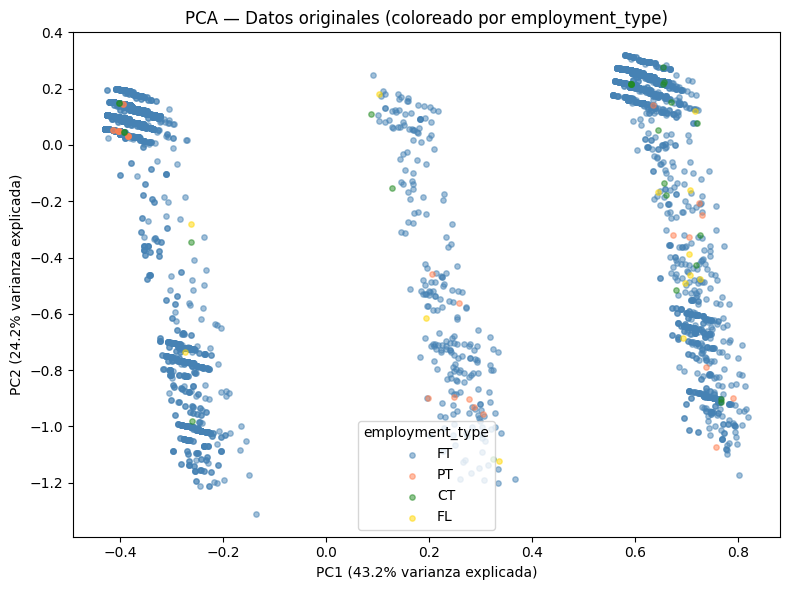

In [ ]:
# --- PCA: reduccion a 2 componentes ---
from sklearn.decomposition import PCA

print(f"=== PCA: {X_mms.shape[1]} features → 2 componentes ===\n")

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_mms)

ev = pca.explained_variance_ratio_
print(f"Varianza explicada:")
print(f"  PC1 : {ev[0]*100:.1f}%")
print(f"  PC2 : {ev[1]*100:.1f}%")
print(f"  Total: {sum(ev)*100:.1f}%")

# Mapa de colores para employment_type
color_map = {'FT': 'steelblue', 'PT': 'coral', 'CT': 'forestgreen', 'FL': 'gold'}

plt.figure(figsize=(8, 6))
for et, color in color_map.items():
    mask = gt_labels == et
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=et, alpha=0.5, s=15)
plt.title('PCA — Datos originales (coloreado por employment_type)')
plt.xlabel(f'PC1 ({ev[0]*100:.1f}% varianza explicada)')
plt.ylabel(f'PC2 ({ev[1]*100:.1f}% varianza explicada)')
plt.legend(title='employment_type')
plt.tight_layout(); plt.show()


## K-Means Clustering <a name="req_kmeans"></a>

Aplicamos K-Means con **n_clusters = 4** porque `employment_type` tiene 4 clases.

Ref. pizarron: *"Aplicar K-Means a su dataset → n_clusters = (num. clases de su dataset)"*

Evaluamos con:
- **Silhouette Score**: que tan compactos y separados estan los clusters (-1 a 1, mayor es mejor)
- **ARI (Adjusted Rand Index)**: que tan bien coinciden los clusters con el ground truth (0=aleatorio, 1=perfecto)


=== K-MEANS (n_clusters=4) ===

Silhouette Score : 0.8788
ARI vs GT        : 0.0053

Distribucion de clusters:
  Cluster 0: 4959 muestras
  Cluster 1: 2723 muestras
  Cluster 2: 702 muestras
  Cluster 3: 743 muestras


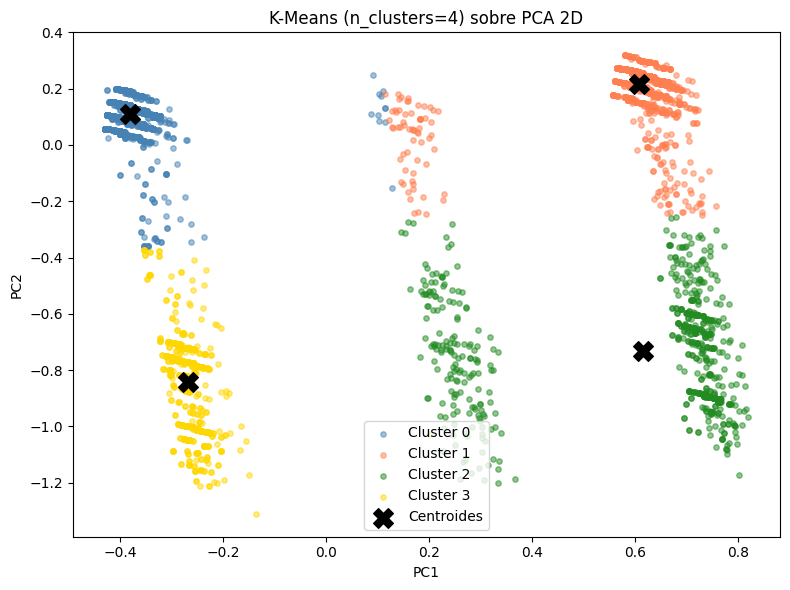

In [ ]:
# --- K-Means ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

N_CLUSTERS = len(gt_unique)   # 4: FT, PT, CT, FL
print(f"=== K-MEANS (n_clusters={N_CLUSTERS}) ===\n")

km        = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
km_labels = km.fit_predict(X_pca)

sil_km = silhouette_score(X_pca, km_labels)
ari_km = adjusted_rand_score(gt_labels, km_labels)

print(f"Silhouette Score : {sil_km:.4f}")
print(f"ARI vs GT        : {ari_km:.4f}")
print()
print("Distribucion de clusters:")
for c, n in zip(*np.unique(km_labels, return_counts=True)):
    print(f"  Cluster {c}: {n} muestras")

colors_km = ['steelblue', 'coral', 'forestgreen', 'gold']
plt.figure(figsize=(8, 6))
for i in range(N_CLUSTERS):
    mask = km_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors_km[i], label=f'Cluster {i}', alpha=0.5, s=15)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroides')
plt.title(f'K-Means (n_clusters={N_CLUSTERS}) sobre PCA 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.tight_layout(); plt.show()


## DBSCAN Clustering <a name="req_dbscan"></a>

DBSCAN agrupa puntos por densidad y detecta ruido automaticamente.
No necesita que se le indique el numero de clusters, pero requiere:
- **eps**: radio de vecindad — que tan lejos puede estar un punto para ser vecino
- **min_samples**: minimo de puntos para que un punto sea nucleo de un cluster

Ref. pizarron: *"Aplicar DBSCAN a su dataset → buscar eps y min_samples adecuados"*

**Metodo para elegir eps:** grafico de k-distancia — el codo indica el eps optimo.


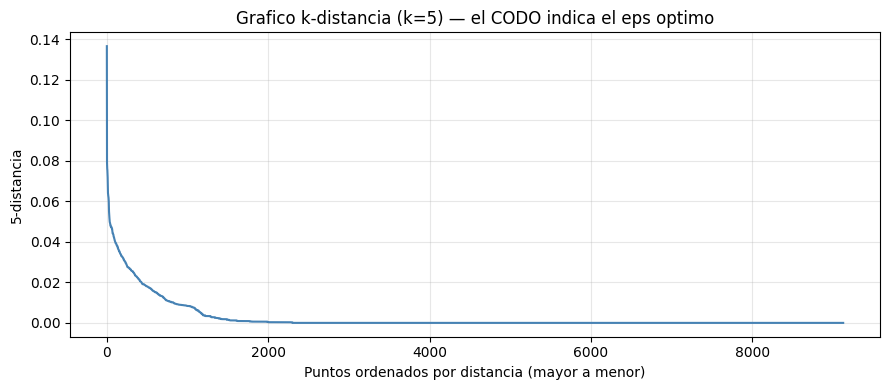

Observa el grafico: el punto donde la curva dobla bruscamente
(el 'codo') es el valor de eps recomendado.

Percentiles de la k-distancia:
  p80: 0.0000
  p85: 0.0000
  p90: 0.0000
  p95: 0.0000


In [ ]:
# --- DBSCAN: grafico k-distancia para elegir eps ---
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 5   # regla general: 2 * n_features (2*2=4, usamos 5)

nbrs      = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_dist    = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(9, 4))
plt.plot(k_dist, color='steelblue', linewidth=1.5)
plt.xlabel('Puntos ordenados por distancia (mayor a menor)')
plt.ylabel(f'{MIN_SAMPLES}-distancia')
plt.title(f'Grafico k-distancia (k={MIN_SAMPLES}) — el CODO indica el eps optimo')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("Observa el grafico: el punto donde la curva dobla bruscamente")
print("(el 'codo') es el valor de eps recomendado.")
print(f"\nPercentiles de la k-distancia:")
for p in [80, 85, 90, 95]:
    print(f"  p{p}: {np.percentile(k_dist, 100-p):.4f}")


=== DBSCAN (eps=0.15, min_samples=5) ===

Clusters encontrados : 3
Puntos de ruido (-1) : 0 (0.0%)

Distribucion:
  Cluster 0: 3191 muestras
  Cluster 1: 246 muestras
  Cluster 2: 5690 muestras

Silhouette Score : 0.6464
ARI vs GT        : 0.0084


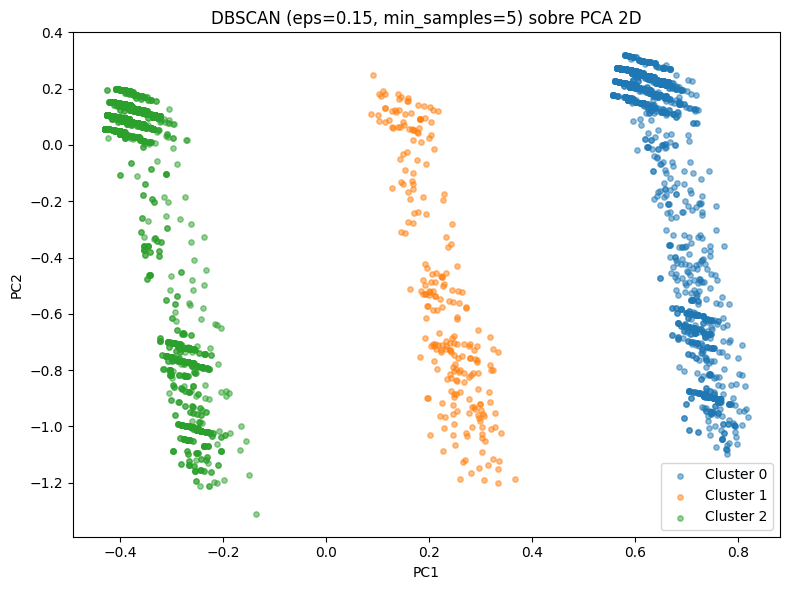

In [ ]:
# --- DBSCAN aplicado ---
from sklearn.cluster import DBSCAN

EPS       = 0.15   # ajustar segun el codo del grafico anterior
MIN_SAMP  = 5

print(f"=== DBSCAN (eps={EPS}, min_samples={MIN_SAMP}) ===\n")

db        = DBSCAN(eps=EPS, min_samples=MIN_SAMP)
db_labels = db.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = int((db_labels == -1).sum())

print(f"Clusters encontrados : {n_clusters_db}")
print(f"Puntos de ruido (-1) : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")
print()
print("Distribucion:")
for c, n in zip(*np.unique(db_labels, return_counts=True)):
    label = "Ruido" if c == -1 else f"Cluster {c}"
    print(f"  {label}: {n} muestras")

if n_clusters_db > 1:
    mask_valid = db_labels != -1
    sil_db = silhouette_score(X_pca[mask_valid], db_labels[mask_valid])
    ari_db = adjusted_rand_score(gt_labels[mask_valid], db_labels[mask_valid])
    print(f"\nSilhouette Score : {sil_db:.4f}")
    print(f"ARI vs GT        : {ari_db:.4f}")
else:
    sil_db = 0.0; ari_db = 0.0
    print("\nDBSCAN no encontro clusters suficientes.")
    print("Prueba ajustando eps hacia arriba (ej: 0.2, 0.3).")

palette_db = plt.cm.tab10.colors
plt.figure(figsize=(8, 6))
for label in sorted(set(db_labels)):
    mask  = db_labels == label
    color = 'lightgray' if label == -1 else palette_db[label % 10]
    lname = 'Ruido' if label == -1 else f'Cluster {label}'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[color], label=lname, alpha=0.5, s=15)
plt.title(f'DBSCAN (eps={EPS}, min_samples={MIN_SAMP}) sobre PCA 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.tight_layout(); plt.show()


## Comparacion Final <a name="req_comparacion"></a>

Comparamos los tres escenarios en un solo grafico:
- **Original**: datos reales coloreados por `employment_type` (ground truth)
- **K-Means**: clusters encontrados automaticamente con n_clusters=4
- **DBSCAN**: clusters por densidad

Ref. pizarron: *"Graficar resultados: Original / KMeans / DBSCAN"*


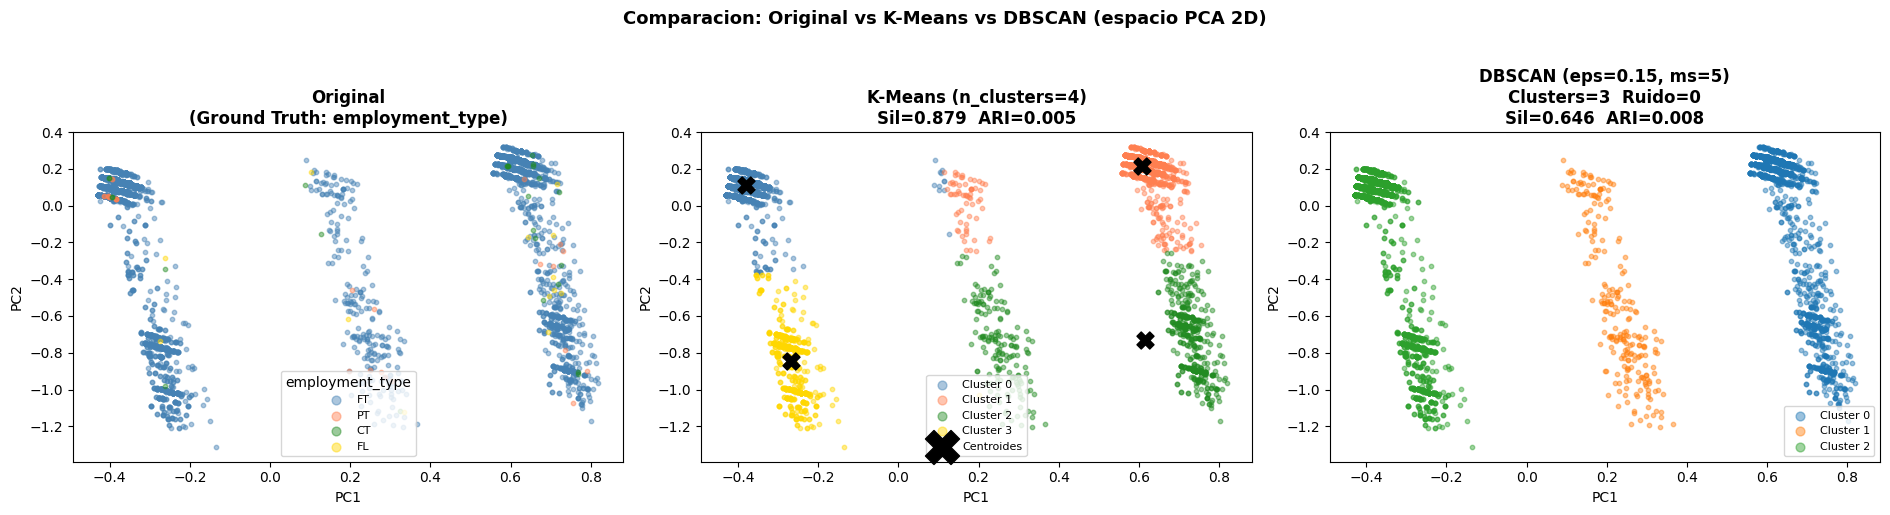


=== RESUMEN CLUSTERING ===
Metodo       Clusters   Silhouette    ARI vs GT
----------------------------------------------
K-Means             4       0.8788       0.0053
DBSCAN              3       0.6464       0.0084

ARI ~ 0  → clusters NO coinciden con employment_type (esperado, el profe lo advirtio)
ARI ~ 1  → coincidencia casi perfecta con ground truth
Silhouette > 0.5 → clusters bien separados e internamente compactos


In [ ]:
# --- Grafica comparativa: Original / KMeans / DBSCAN ---
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Original
for et, color in color_map.items():
    mask = gt_labels == et
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=et, alpha=0.45, s=10)
axes[0].set_title('Original\n(Ground Truth: employment_type)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(title='employment_type', fontsize=8, markerscale=2)

# K-Means
for i in range(N_CLUSTERS):
    mask = km_labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_km[i], label=f'Cluster {i}', alpha=0.45, s=10)
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c='black', marker='X', s=150, zorder=5, label='Centroides')
axes[1].set_title(f'K-Means (n_clusters={N_CLUSTERS})\nSil={sil_km:.3f}  ARI={ari_km:.3f}',
                  fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8, markerscale=2)

# DBSCAN
for label in sorted(set(db_labels)):
    mask  = db_labels == label
    color = 'lightgray' if label == -1 else palette_db[label % 10]
    lname = 'Ruido' if label == -1 else f'Cluster {label}'
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color], label=lname, alpha=0.45, s=10)
title_db = (f'DBSCAN (eps={EPS}, ms={MIN_SAMP})\n'
            f'Clusters={n_clusters_db}  Ruido={n_noise}')
if n_clusters_db > 1:
    title_db += f'\nSil={sil_db:.3f}  ARI={ari_db:.3f}'
axes[2].set_title(title_db, fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(fontsize=8, markerscale=2)

plt.suptitle('Comparacion: Original vs K-Means vs DBSCAN (espacio PCA 2D)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Tabla resumen
print("\n=== RESUMEN CLUSTERING ===")
print(f"{'Metodo':<10} {'Clusters':>10} {'Silhouette':>12} {'ARI vs GT':>12}")
print("-" * 46)
print(f"{'K-Means':<10} {N_CLUSTERS:>10} {sil_km:>12.4f} {ari_km:>12.4f}")
if n_clusters_db > 1:
    print(f"{'DBSCAN':<10} {n_clusters_db:>10} {sil_db:>12.4f} {ari_db:>12.4f}")
else:
    print(f"{'DBSCAN':<10} {n_clusters_db:>10}        N/A          N/A")

print()
print("ARI ~ 0  → clusters NO coinciden con employment_type (esperado, el profe lo advirtio)")
print("ARI ~ 1  → coincidencia casi perfecta con ground truth")
print("Silhouette > 0.5 → clusters bien separados e internamente compactos")
